# `find_and_suppress` on MIDOG++ -- raw-annotation-seed, most-minimal-configuration run

**Purpose.** [`find_and_suppress_midog_simple.ipynb`](find_and_suppress_midog_simple.ipynb)
already strips augmentation and multi-scale down to nothing (`n_angles=1`, `flips=(False,)`,
`scales=(1.0,)` -- all `FSConfig` defaults as of `Research Logs/design_choices.md` section 6),
but it still refines the seed's template box with Otsu-threshold bbox tightening
(`seed_selection.tighten_box_otsu`, sections 1-2 of the same log) before matching.

This notebook drops that last piece of refinement too: **the seed template is the raw
50x50 px pathologist annotation itself**, centred on the click, with no Otsu/connected-
component tightening at all. That is `tighten_bbox=False` (`Research Logs/design_choices.md`,
section 8 -- "No-bbox-tightening variant: agreement-only seed selection, native box size"),
implemented and smoke-tested there but not yet run as an actual comparison. This notebook is
that run.

- **No bbox tightening** -- `tighten_bbox=False` everywhere below. Seed selection is
  pathologist agreement + the border-distance filter only; the Otsu/CC foreground filter
  never runs, so a seed is never excluded for having its click land outside a foreground
  component either. The template keeps `FSConfig.base_size`'s native size -- 51 px, the odd
  window that covers the annotation's own +-25 px extent and centres the click at its middle
  pixel. **51, not 50: the annotation box is 50x50 (`dataset.BOX_SIZE`), but the template
  reader needs an odd size so the click lands on a single centre pixel rather than between
  four; 51 is that box, unrefined, not a tightened or resized one.**
- **No augmentation** -- one template per seed, angle 0, no flip (`FSConfig`'s own default).
- **No multi-scale** -- one template size, the raw 51 px box (`FSConfig`'s own default).
- **Three-channel comparison** -- raw RGB, hematoxylin (colour-deconvolved), and
  `gray_inverted` (`255 - grayscale`), same as the simple notebook, with the same fixed seed
  per domain image across all three (seed selection under `tighten_bbox=False` never reads
  the structural channel at all -- see the sanity check below).

Same seven ROIs (one per tumour domain, the pathologist-agreement seed-selection rule) as the
other two notebooks. All logic lives in [`midog_utils/`](midog_utils/); this notebook only
calls it -- no changes to that package.

**Environment.** `requirements-midog-utils.txt` (numpy < 2, pinned opencv/tifffile) -- run
with the `midog-anaconda3` kernel.

In [1]:
import sys, time
sys.path.insert(0, '..') if 'midog_utils' not in __import__('os').listdir('.') else None

import numpy as np, pandas as pd, matplotlib.pyplot as plt

from midog_utils import dataset as ds, channels as ch, template_match as tm
from midog_utils import find_and_suppress as fs, evaluate as ev, experiment as ex, viz

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 60)

images, annotations = ds.load_annotations('databases/MIDOG++.json')
ds.check_invariants(annotations)          # every bbox is 50x50 and TLBR, or this raises
print(f'{len(images)} annotated images, {len(annotations)} annotations')

503 annotated images, 26286 annotations


## Which images

Same rule as the other two notebooks: one ROI per tumour domain, the downloaded image with
the most mitotic figures (ties to the lower id). See
[`find_and_suppress_midog.ipynb`](find_and_suppress_midog.ipynb) for why this is an
optimistic selection rather than a representative one -- unchanged here, since the point of
this notebook is the seed-refinement question, not the image-selection rule.

In [2]:
selection = ex.select_domain_images(images, annotations)
selection[['image_id', 'file_name', 'tumor_type', 'n_mitotic']]

,image_id,file_name,tumor_type,n_mitotic
0,301,301.tiff,canine cutaneous mast cell tumor,218
1,201,201.tiff,canine lung cancer,18
2,246,246.tiff,canine lymphosarcoma,116
3,405,405.tiff,canine soft tissue sarcoma,14
4,2,002.tiff,human breast cancer,9
5,506,506.tiff,human melanoma,12
6,350,350.tiff,human neuroendocrine tumor,4


## Configuration

`channel='rgb'` is the only `FSConfig` override for the first pass -- `base_size=51`,
`n_angles=1`, `flips=(False,)`, `scales=(1.0,)`, `score_threshold=0.5` are all `FSConfig`'s
own defaults. The thing that actually makes this notebook different from
`find_and_suppress_midog_simple.ipynb` is not in `cfg` at all: it's `tighten_bbox=False`,
passed to `experiment.run_experiment` below, which skips `seed_selection.tighten_box_otsu`
entirely and leaves the template at `cfg.base_size`'s native 51 px rather than resizing it to
a tightened box.

In [3]:
cfg = fs.FSConfig(channel='rgb')
print(cfg)
print(f'\n{cfg.n_augmentations} augmentation(s) per run '
      f'({cfg.n_angles} rotation x {len(cfg.flips)} flip x {len(cfg.scales)} scale) -- '
      'the template is the raw, untightened annotation box, untransformed.')

FSConfig(channel='rgb', base_size=51, patch_size=73, scales=(1.0,), n_angles=1, flips=(False,), peak_min_distance=7, score_threshold=0.5, max_peaks=250000, nms_radius=None, self_hit_radius=5.0, max_detections=1000000000, scale_normalize=False)

1 augmentation(s) per run (1 rotation x 1 flip x 1 scale) -- the template is the raw, untightened annotation box, untransformed.


## Run

One raw-RGB correlation per image against the untightened 51 px template (no augmentation
bank, no Otsu/CC step), plus the nucleus-blob and random-in-tissue baselines for context.

In [4]:
t0 = time.time()
results, metrics, detections = ex.run_experiment(
    selection, annotations, cfg=cfg, seed=0, tighten_bbox=False)
print(f'\ntotal {time.time()-t0:.0f}s')

metrics.to_csv('results/fs_raw_seed_rgb_metrics.csv', index=False)
detections.to_csv('results/fs_raw_seed_rgb_detections.csv', index=False)

=== 301.tiff  (canine cutaneous mast cell tumor, 218 mitotic) 
    recall@K=0.018  attraction@K=0.055  coverage=0.08  (16s)
=== 201.tiff  (canine lung cancer, 18 mitotic) 
    recall@K=0.000  attraction@K=0.020  coverage=0.09  (27s)
=== 246.tiff  (canine lymphosarcoma, 116 mitotic) 
    recall@K=0.035  attraction@K=0.008  coverage=0.00  (39s)
=== 405.tiff  (canine soft tissue sarcoma, 14 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.24  (17s)
=== 002.tiff  (human breast cancer, 9 mitotic) 
    recall@K=0.250  attraction@K=0.000  coverage=0.16  (21s)
=== 506.tiff  (human melanoma, 12 mitotic) 
    recall@K=0.091  attraction@K=0.000  coverage=0.08  (15s)
=== 350.tiff  (human neuroendocrine tumor, 4 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.08  (15s)

total 150s


## Results

### Headline: `recall@K`

`K` = the number of mitotic figures in that ROI, minus the seed. Read `coverage_frac`
alongside it (see `evaluate.py`'s module docstring on why a saturated list makes full-list
recall uninformative).

In [5]:
ex.summary_table(metrics)

,tumor_type,file_name,method,n_gt_mitotic_eval,n_lookalike_gt,recall_at_k,lookalike_attraction_at_k,topk_tp,topk_fp_lookalike,topk_fp_unannotated,sens@8fp_mm2,sens@64fp_mm2,n_unanimous,recall_unanimous_at_k,n_contested,recall_contested_at_k,max_detection_score,n_detections_total
0,canine cutaneous mast cell tumor,301.tiff,find_and_suppress,217,109,0.018433,0.055046,4,6,207,0.004608,0.004608,163,0.018405,54,0.018519,0.698913,944
1,canine lung cancer,201.tiff,find_and_suppress,17,49,0.000000,0.020408,0,1,16,0.000000,0.000000,6,0.000000,11,0.000000,0.682228,1053
2,canine lymphosarcoma,246.tiff,find_and_suppress,115,123,0.034783,0.008130,4,1,2,0.034783,0.034783,99,0.040404,16,0.000000,0.575873,7
3,canine soft tissue sarcoma,405.tiff,find_and_suppress,13,19,0.000000,0.000000,0,0,13,0.000000,0.076923,9,0.000000,4,0.000000,0.834864,2815
4,human breast cancer,002.tiff,find_and_suppress,8,7,0.250000,0.000000,2,0,6,0.250000,0.500000,6,0.333333,2,0.000000,0.792036,1860
5,human melanoma,506.tiff,find_and_suppress,11,12,0.090909,0.000000,1,0,10,0.090909,0.090909,7,0.142857,4,0.000000,0.688062,914
6,human neuroendocrine tumor,350.tiff,find_and_suppress,3,16,0.000000,0.000000,0,0,3,0.000000,0.000000,0,NaN,3,0.000000,0.724168,956


### Against the baselines

`nucleus_blobs` (any dark blob, hematoxylin channel) and `random_in_tissue` (the floor). If
raw-RGB, single untightened-template matching does not beat the blob detector at an equal
budget, that is the finding for this configuration.

In [6]:
pivot = metrics.pivot_table(index=['tumor_type', 'file_name'], columns='method',
                            values='recall_at_k').round(3)
pivot['lift_vs_blobs'] = (pivot['find_and_suppress'] /
                          pivot['nucleus_blobs'].replace(0, np.nan)).round(2)
pivot

,method,find_and_suppress,nucleus_blobs,random_in_tissue,lift_vs_blobs
tumor_type,file_name,,,,
canine cutaneous mast cell tumor,301.tiff,0.018,0.599,0.009,0.03
canine lung cancer,201.tiff,0.000,0.235,0.000,0.00
canine lymphosarcoma,246.tiff,0.035,0.322,0.000,0.11
canine soft tissue sarcoma,405.tiff,0.000,0.000,0.000,NaN
human breast cancer,002.tiff,0.250,0.000,0.000,NaN
human melanoma,506.tiff,0.091,0.000,0.000,NaN
human neuroendocrine tumor,350.tiff,0.000,0.000,0.000,NaN


### Every detection, not just the top K

Bucketed by what it landed on, with no top-K budget applied.

In [7]:
ex.full_list_table(metrics)

,tumor_type,file_name,all_n_detections,coverage_frac,all_tp,all_fp_lookalike,all_fp_unannotated,all_matched_any_gt,all_matched_frac,all_precision_mitotic,all_mitotic_gt_found,all_mitotic_gt_missed,all_lookalike_gt_found,all_lookalike_gt_missed
0,canine cutaneous mast cell tumor,301.tiff,944,0.0812,25,15,904,40,0.042373,0.026483,25,192,15,94
1,canine lung cancer,201.tiff,1053,0.0902,3,4,1046,7,0.006648,0.002849,3,14,4,45
2,canine lymphosarcoma,246.tiff,7,0.0006,4,1,2,5,0.714286,0.571429,4,111,1,122
3,canine soft tissue sarcoma,405.tiff,2815,0.2358,10,8,2797,18,0.006394,0.003552,10,3,8,11
4,human breast cancer,002.tiff,1860,0.1570,7,6,1847,13,0.006989,0.003763,7,1,6,1
5,human melanoma,506.tiff,914,0.0774,3,2,909,5,0.005470,0.003282,3,8,2,10
6,human neuroendocrine tumor,350.tiff,956,0.0810,1,5,950,6,0.006276,0.001046,1,2,5,11


### `tightened_base_size` under `tighten_bbox=False`

Under this notebook's setting the template is never actually tightened, so this column
should read exactly `cfg.base_size` (51) on every row -- checked, not assumed, since it feeds
the sanity check further down too.

In [8]:
fs_rows = metrics[metrics.method == 'find_and_suppress']
assert (fs_rows['tightened_base_size'] == cfg.base_size).all(), \
    'tighten_bbox=False should leave every row at cfg.base_size (51), unrefined'
print(f"OK: tightened_base_size == cfg.base_size ({cfg.base_size}) on all "
      f"{len(fs_rows)} rows -- the template really is the raw, untightened annotation box.")

fs_rows[['tumor_type', 'file_name', 'seed_ann_id', 'tightened_base_size',
        'seed_agreement_flagged', 'n_unanimous', 'recall_unanimous_at_k',
        'n_contested', 'recall_contested_at_k']].sort_values('tumor_type').reset_index(drop=True)

OK: tightened_base_size == cfg.base_size (51) on all 7 rows -- the template really is the raw, untightened annotation box.


,tumor_type,file_name,seed_ann_id,tightened_base_size,seed_agreement_flagged,n_unanimous,recall_unanimous_at_k,n_contested,recall_contested_at_k
0,canine cutaneous mast cell tumor,301.tiff,14969,51.0,False,163,0.018405,54,0.018519
1,canine lung cancer,201.tiff,4457,51.0,False,6,0.000000,11,0.000000
2,canine lymphosarcoma,246.tiff,6548,51.0,False,99,0.040404,16,0.000000
3,canine soft tissue sarcoma,405.tiff,20563,51.0,False,9,0.000000,4,0.000000
4,human breast cancer,002.tiff,18,51.0,False,6,0.333333,2,0.000000
5,human melanoma,506.tiff,24233,51.0,False,7,0.142857,4,0.000000
6,human neuroendocrine tumor,350.tiff,18164,51.0,True,0,NaN,3,0.000000


### FROC

Sensitivity against false positives per mm^2, this configuration only.

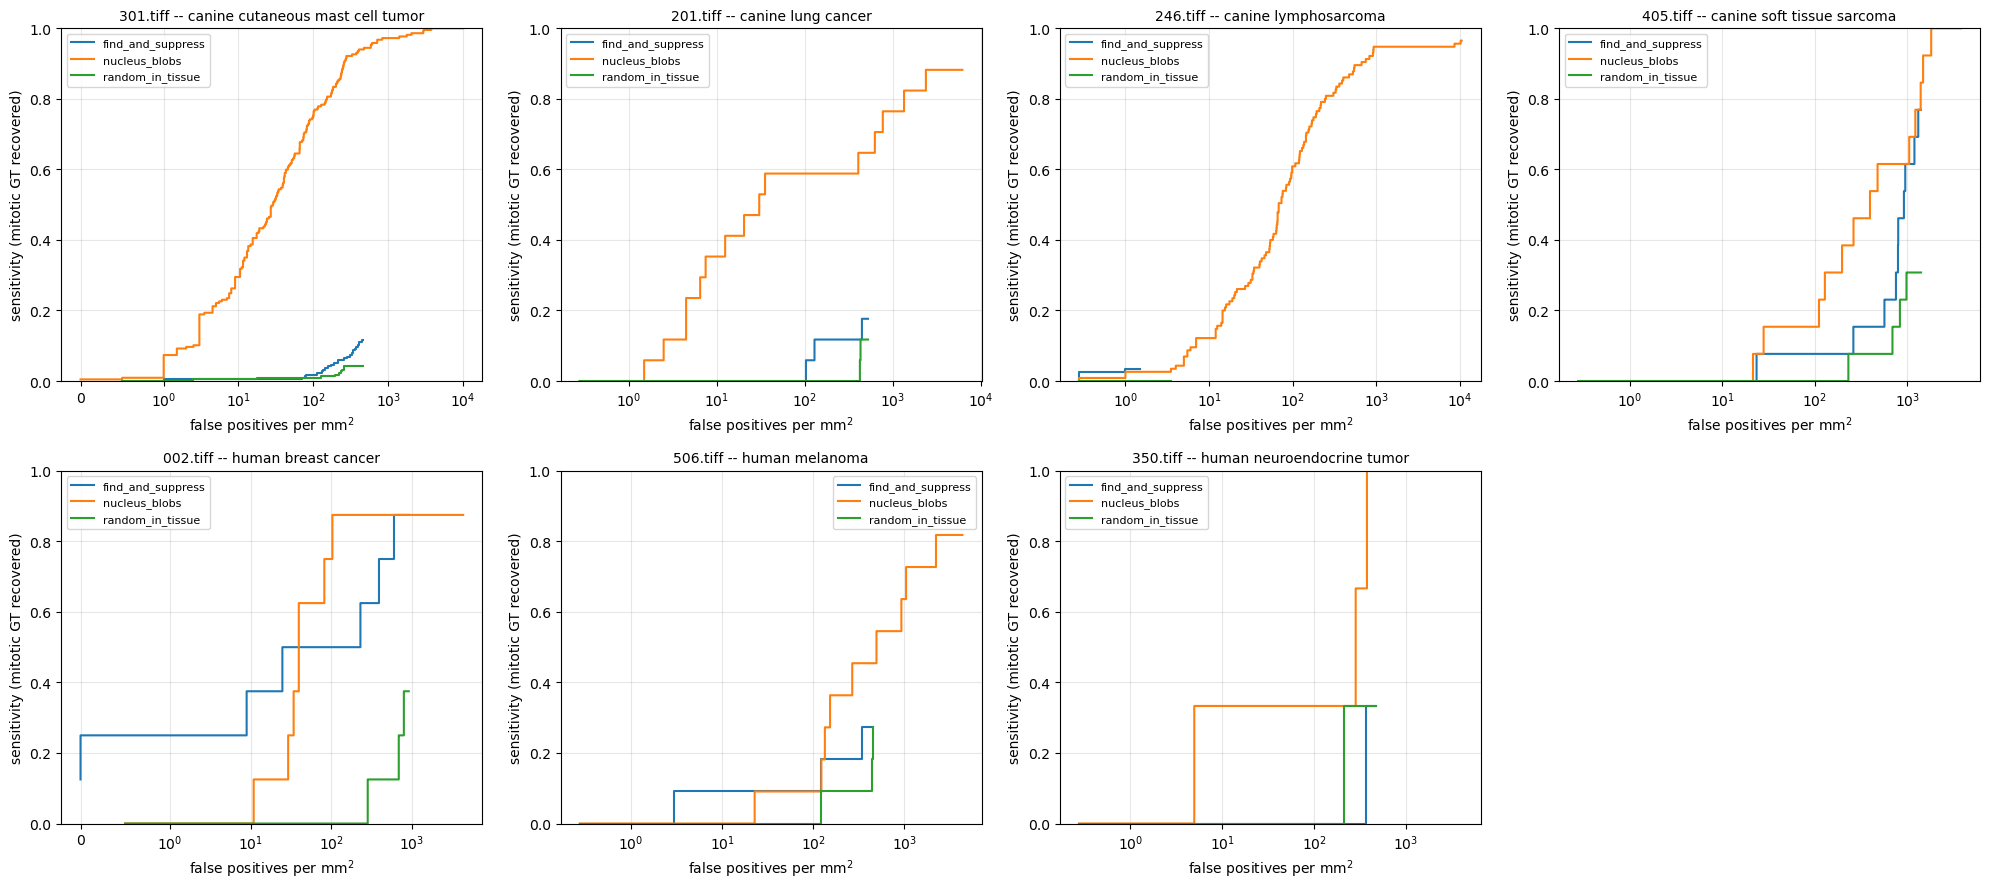

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, (fn, res) in zip(axes.ravel(), results.items()):
    curves = [('find_and_suppress', *res['curve'])]
    if 'baseline_blobs_curve' in res:
        curves.append(('nucleus_blobs', *res['baseline_blobs_curve']))
        curves.append(('random_in_tissue', *res['baseline_random_curve']))
    tumor = selection.loc[selection.file_name == fn, 'tumor_type'].iloc[0]
    viz.froc_plot(curves, ax=ax, title=f'{fn} -- {tumor}')
for ax in axes.ravel()[len(results):]:
    ax.axis('off')
fig.tight_layout(); plt.show()

### Where the detections land

White star = the seed. Red = ground-truth mitotic figures, yellow = ground-truth
look-alikes. Detections are the top-K only, coloured by bucket, drawn at the match radius.
The seed's own white-starred box is the raw 51 px annotation -- there is no tightened box to
compare it against in this notebook.

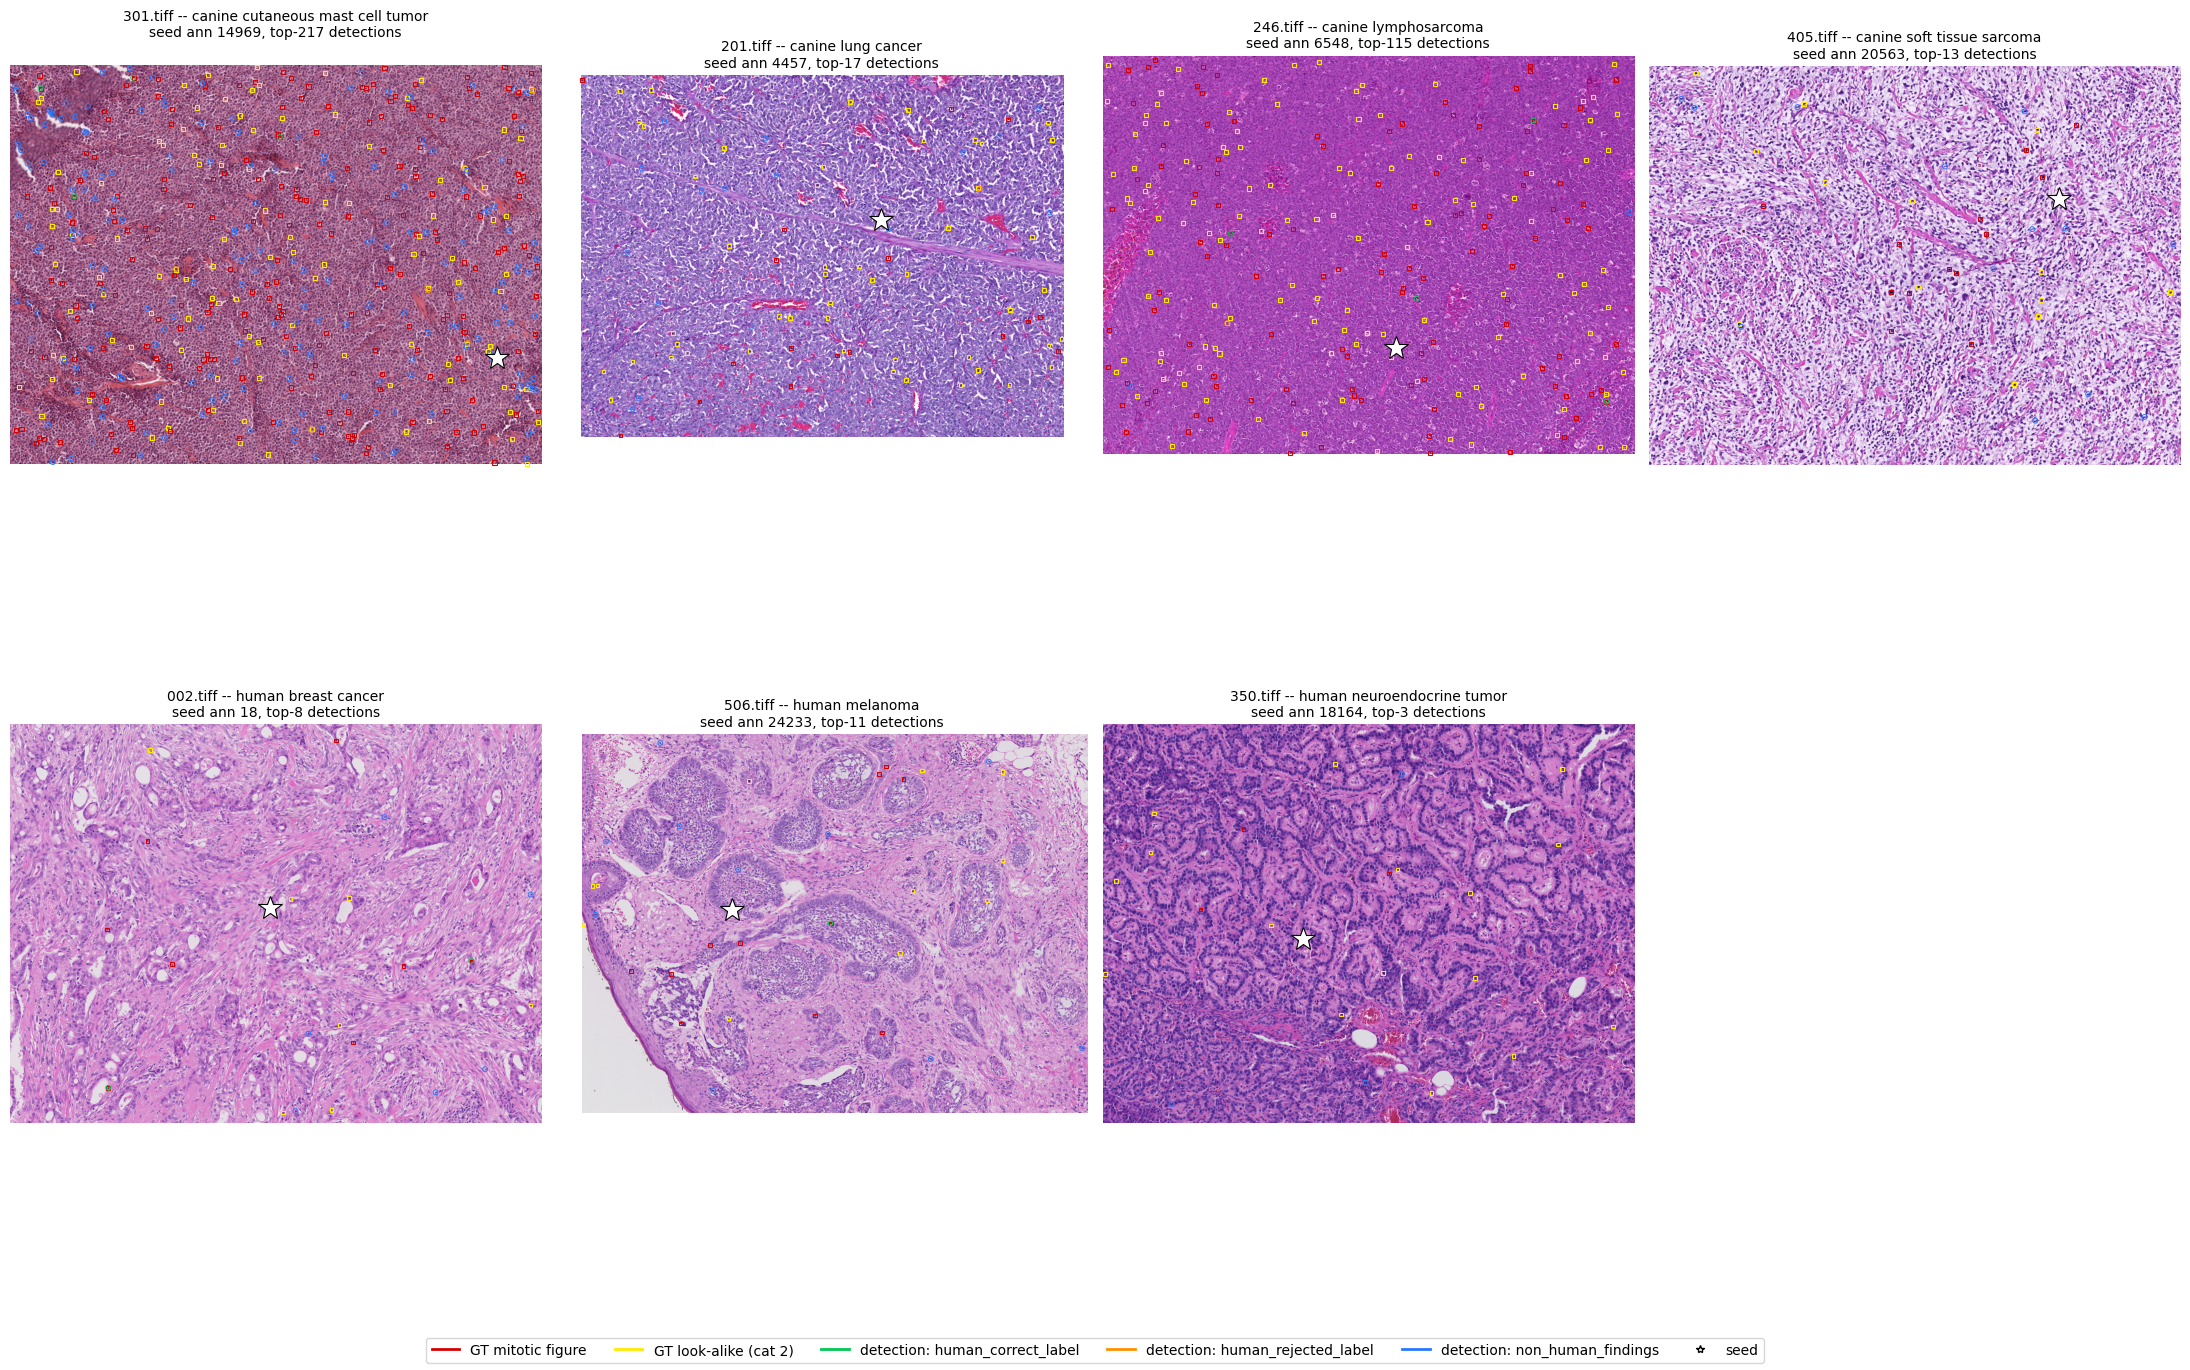

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(22, 15))
for ax, (fn, res) in zip(axes.ravel(), results.items()):
    rgb = ds.load_roi(f'images/{fn}')
    k = res['metrics'][0]['k']
    tumor = selection.loc[selection.file_name == fn, 'tumor_type'].iloc[0]
    viz.overlay(rgb, res['gt'], res['detections'], (res['seed'].cx, res['seed'].cy),
                ax=ax, downsample=4, top_n=k, radius=res['radius'],
                title=f"{fn} -- {tumor}\nseed ann {int(res['seed'].ann_id)}, top-{k} detections")
    del rgb
for ax in axes.ravel()[len(results):]:
    ax.axis('off')
fig.legend(handles=viz.legend_handles(), loc='lower center', ncol=6, fontsize=10)
fig.tight_layout(rect=(0, 0.03, 1, 1)); plt.show()

## Channel comparison: hematoxylin and `gray_inverted`

Same untightened pipeline -- raw 51 px template, no augmentation, no multi-scale,
`tighten_bbox=False` -- run twice more, changing only `FSConfig.channel`.

**Why this is a clean channel-only ablation.** `experiment.run_experiment` builds each
image's RNG from `(seed, image_id)` alone, and under `tighten_bbox=False`,
`seed_selection.pick_seed` runs pathologist agreement and the border filter only -- neither
reads `structural_channel` at all (the Otsu/CC foreground filter, the one step that does
read it, never runs). So calling `run_experiment(..., seed=0)` again with only `channel`
changed reproduces the exact same seed annotation on every image regardless of channel --
confirmed below rather than assumed. `tightened_base_size` needs no cross-channel check here
either, since it is pinned to `cfg.base_size` (51) by construction whenever `tighten_bbox=False`.

**Baselines are not re-run** -- they don't depend on `FSConfig.channel` (`nucleus_blobs`
converts its own hematoxylin channel from `rgb` directly, never through `cfg`); the
comparison already computed above stands for both new channels too.

In [11]:
cfg_hematoxylin = fs.FSConfig(channel='hematoxylin')
t0 = time.time()
results_hem, metrics_hem, detections_hem = ex.run_experiment(
    selection, annotations, cfg=cfg_hematoxylin, seed=0, run_baselines=False, tighten_bbox=False)
print(f'\ntotal {time.time()-t0:.0f}s')

metrics_hem.to_csv('results/fs_raw_seed_hematoxylin_metrics.csv', index=False)
detections_hem.to_csv('results/fs_raw_seed_hematoxylin_detections.csv', index=False)

=== 301.tiff  (canine cutaneous mast cell tumor, 218 mitotic) 
    recall@K=0.018  attraction@K=0.046  coverage=0.07  (8s)
=== 201.tiff  (canine lung cancer, 18 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.08  (8s)
=== 246.tiff  (canine lymphosarcoma, 116 mitotic) 
    recall@K=0.165  attraction@K=0.057  coverage=0.01  (7s)
=== 405.tiff  (canine soft tissue sarcoma, 14 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.27  (7s)
=== 002.tiff  (human breast cancer, 9 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.30  (10s)
=== 506.tiff  (human melanoma, 12 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.20  (10s)
=== 350.tiff  (human neuroendocrine tumor, 4 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.25  (8s)

total 59s


In [12]:
cfg_gray_inverted = fs.FSConfig(channel='gray_inverted')
t0 = time.time()
results_gray, metrics_gray, detections_gray = ex.run_experiment(
    selection, annotations, cfg=cfg_gray_inverted, seed=0, run_baselines=False, tighten_bbox=False)
print(f'\ntotal {time.time()-t0:.0f}s')

metrics_gray.to_csv('results/fs_raw_seed_gray_inverted_metrics.csv', index=False)
detections_gray.to_csv('results/fs_raw_seed_gray_inverted_detections.csv', index=False)

=== 301.tiff  (canine cutaneous mast cell tumor, 218 mitotic) 
    recall@K=0.018  attraction@K=0.064  coverage=0.11  (4s)
=== 201.tiff  (canine lung cancer, 18 mitotic) 
    recall@K=0.000  attraction@K=0.020  coverage=0.12  (4s)
=== 246.tiff  (canine lymphosarcoma, 116 mitotic) 
    recall@K=0.026  attraction@K=0.008  coverage=0.00  (4s)
=== 405.tiff  (canine soft tissue sarcoma, 14 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.27  (4s)
=== 002.tiff  (human breast cancer, 9 mitotic) 
    recall@K=0.250  attraction@K=0.000  coverage=0.20  (4s)
=== 506.tiff  (human melanoma, 12 mitotic) 
    recall@K=0.091  attraction@K=0.000  coverage=0.11  (5s)
=== 350.tiff  (human neuroendocrine tumor, 4 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.10  (4s)

total 27s


### Sanity check: is this actually apples-to-apples?

Before trusting any difference between channels as a channel effect, confirm the three runs
agree on everything that is *supposed* to be identical: which annotation was the seed, and
that the template stayed at the raw 51 px size in every case (no tightening anywhere). Also
confirm the three `FSConfig`s differ in `channel` and nothing else.

In [13]:
from dataclasses import asdict, fields

# 1. cfg objects differ only in `channel`.
cfg_rgb = cfg
diffs = {f.name for f in fields(cfg_rgb)
         if not (asdict(cfg_rgb)[f.name] == asdict(cfg_hematoxylin)[f.name] == asdict(cfg_gray_inverted)[f.name])}
assert diffs == {'channel'}, f'FSConfig fields other than channel differ: {diffs}'
print('OK: the three configs differ only in `channel`.')

# 2. Same seed annotation, per image, across all three channels.
key_cols = ['file_name', 'seed_ann_id', 'tightened_base_size']
m_rgb = metrics[metrics.method == 'find_and_suppress'][key_cols].set_index('file_name')
m_h = metrics_hem[key_cols].set_index('file_name')
m_g = metrics_gray[key_cols].set_index('file_name')

seed_mismatch = m_rgb.index[(m_rgb.seed_ann_id != m_h.seed_ann_id) | (m_rgb.seed_ann_id != m_g.seed_ann_id)]
assert len(seed_mismatch) == 0, f'seed_ann_id differs by channel on: {list(seed_mismatch)}'
print('OK: same seed_ann_id on all 7 images across rgb/hematoxylin/gray_inverted.')

# 3. Every row, every channel: tightened_base_size == cfg.base_size (51) -- the template
# really is untightened everywhere, not just in the rgb pass checked above.
for name, m in [('rgb', m_rgb), ('hematoxylin', m_h), ('gray_inverted', m_g)]:
    assert (m['tightened_base_size'] == cfg.base_size).all(), \
        f'{name}: tightened_base_size should be {cfg.base_size} (untightened) on every row'
print(f'OK: tightened_base_size == {cfg.base_size} on all 21 rows (7 images x 3 channels).')

m_rgb.join(m_h, lsuffix='_rgb', rsuffix='_hem').join(m_g.add_suffix('_gray'))

OK: the three configs differ only in `channel`.
OK: same seed_ann_id on all 7 images across rgb/hematoxylin/gray_inverted.
OK: tightened_base_size == 51 on all 21 rows (7 images x 3 channels).


,seed_ann_id_rgb,tightened_base_size_rgb,seed_ann_id_hem,tightened_base_size_hem,seed_ann_id_gray,tightened_base_size_gray
file_name,,,,,,
301.tiff,14969,51.0,14969,51,14969,51
201.tiff,4457,51.0,4457,51,4457,51
246.tiff,6548,51.0,6548,51,6548,51
405.tiff,20563,51.0,20563,51,20563,51
002.tiff,18,51.0,18,51,18,51
506.tiff,24233,51.0,24233,51,24233,51
350.tiff,18164,51.0,18164,51,18164,51


### Headline comparison: `recall@K` by channel

Same `K` and the same seed/template per image across all three columns, so a difference here
is attributable to what the correlation actually searched in.

In [14]:
combined = pd.concat([
    metrics[metrics.method == 'find_and_suppress'],
    metrics_hem, metrics_gray,
], ignore_index=True)
combined.to_csv('results/fs_raw_seed_channel_comparison_metrics.csv', index=False)

channel_pivot = combined.pivot_table(
    index=['tumor_type', 'file_name'], columns='channel',
    values=['recall_at_k', 'lookalike_attraction_at_k', 'coverage_frac',
            'n_detections_total', 'max_detection_score']
).round(3)
channel_pivot

coverage_frac                    lookalike_attraction_at_k                    max_detection_score                    n_detections_total              \
channel                                    gray_inverted hematoxylin    rgb             gray_inverted hematoxylin    rgb       gray_inverted hematoxylin    rgb      gray_inverted hematoxylin   
tumor_type                       file_name                                                                                                                                                       
canine cutaneous mast cell tumor 301.tiff          0.109       0.065  0.081                     0.064       0.046  0.055               0.717       0.680  0.699             1280.0       755.0   
canine lung cancer               201.tiff          0.119       0.079  0.090                     0.020       0.000  0.020               0.702       0.666  0.682             1393.0       907.0   
canine lymphosarcoma             246.tiff          0.001       0.005  0.001                     0.008       0.057  0.008               0.584       0.660  0.576                7.0        59.0   
canine soft tissue sarcoma       405.tiff          0.272       0.266  0.236                     0.000       0.000  0.000               0.850       0.841  0.835             3256.0      3209.0   
human breast cancer              002.tiff          0.202       0.298  0.157                     0.000       0.000  0.000               0.801       0.828  0.792             2419.0      3638.0   
human melanoma                   506.tiff          0.106       0.204  0.077                     0.000       0.000  0.000               0.700       0.754  0.688             1259.0      2507.0   
human neuroendocrine tumor       350.tiff          0.099       0.247  0.081                     0.000       0.000  0.000               0.746       0.795  0.724             1181.0      3002.0   

                                                     recall_at_k                     
channel                                        rgb gray_inverted hematoxylin    rgb  
tumor_type                       file_name                                           
canine cutaneous mast cell tumor 301.tiff    944.0         0.018       0.018  0.018  
canine lung cancer               201.tiff   1053.0         0.000       0.000  0.000  
canine lymphosarcoma             246.tiff      7.0         0.026       0.165  0.035  
canine soft tissue sarcoma       405.tiff   2815.0         0.000       0.000  0.000  
human breast cancer              002.tiff   1860.0         0.250       0.000  0.250  
human melanoma                   506.tiff    914.0         0.091       0.000  0.091  
human neuroendocrine tumor       350.tiff    956.0         0.000       0.000  0.000

### Every detection, not just top-K -- by channel

In [15]:
full_list_rows = []
for chan, g in combined.groupby('channel'):
    t = ex.full_list_table(g, method=None)
    t.insert(0, 'channel', chan)
    full_list_rows.append(t)
full_list_by_channel = pd.concat(full_list_rows, ignore_index=True).sort_values(['tumor_type', 'channel']).reset_index(drop=True)
full_list_by_channel

,channel,tumor_type,file_name,all_n_detections,coverage_frac,all_tp,all_fp_lookalike,all_fp_unannotated,all_matched_any_gt,all_matched_frac,all_precision_mitotic,all_mitotic_gt_found,all_mitotic_gt_missed,all_lookalike_gt_found,all_lookalike_gt_missed
0,gray_inverted,canine cutaneous mast cell tumor,301.tiff,1280,0.1090,33,18,1229,51,0.039844,0.025781,33,184,18,91
1,hematoxylin,canine cutaneous mast cell tumor,301.tiff,755,0.0653,20,7,728,27,0.035762,0.026490,20,197,7,102
2,rgb,canine cutaneous mast cell tumor,301.tiff,944,0.0812,25,15,904,40,0.042373,0.026483,25,192,15,94
3,gray_inverted,canine lung cancer,201.tiff,1393,0.1189,3,6,1384,9,0.006461,0.002154,3,14,6,43
4,hematoxylin,canine lung cancer,201.tiff,907,0.0790,8,17,882,25,0.027563,0.008820,8,9,17,32
5,rgb,canine lung cancer,201.tiff,1053,0.0902,3,4,1046,7,0.006648,0.002849,3,14,4,45
6,gray_inverted,canine lymphosarcoma,246.tiff,7,0.0006,3,1,3,4,0.571429,0.428571,3,112,1,122
7,hematoxylin,canine lymphosarcoma,246.tiff,59,0.0051,19,7,33,26,0.440678,0.322034,19,96,7,116
8,rgb,canine lymphosarcoma,246.tiff,7,0.0006,4,1,2,5,0.714286,0.571429,4,111,1,122
9,gray_inverted,canine soft tissue sarcoma,405.tiff,3256,0.2715,10,9,3237,19,0.005835,0.003071,10,3,9,10


### FROC by channel

One panel per image, three curves (rgb / hematoxylin / gray_inverted) -- no baselines here,
since the point of this figure is the channel comparison.

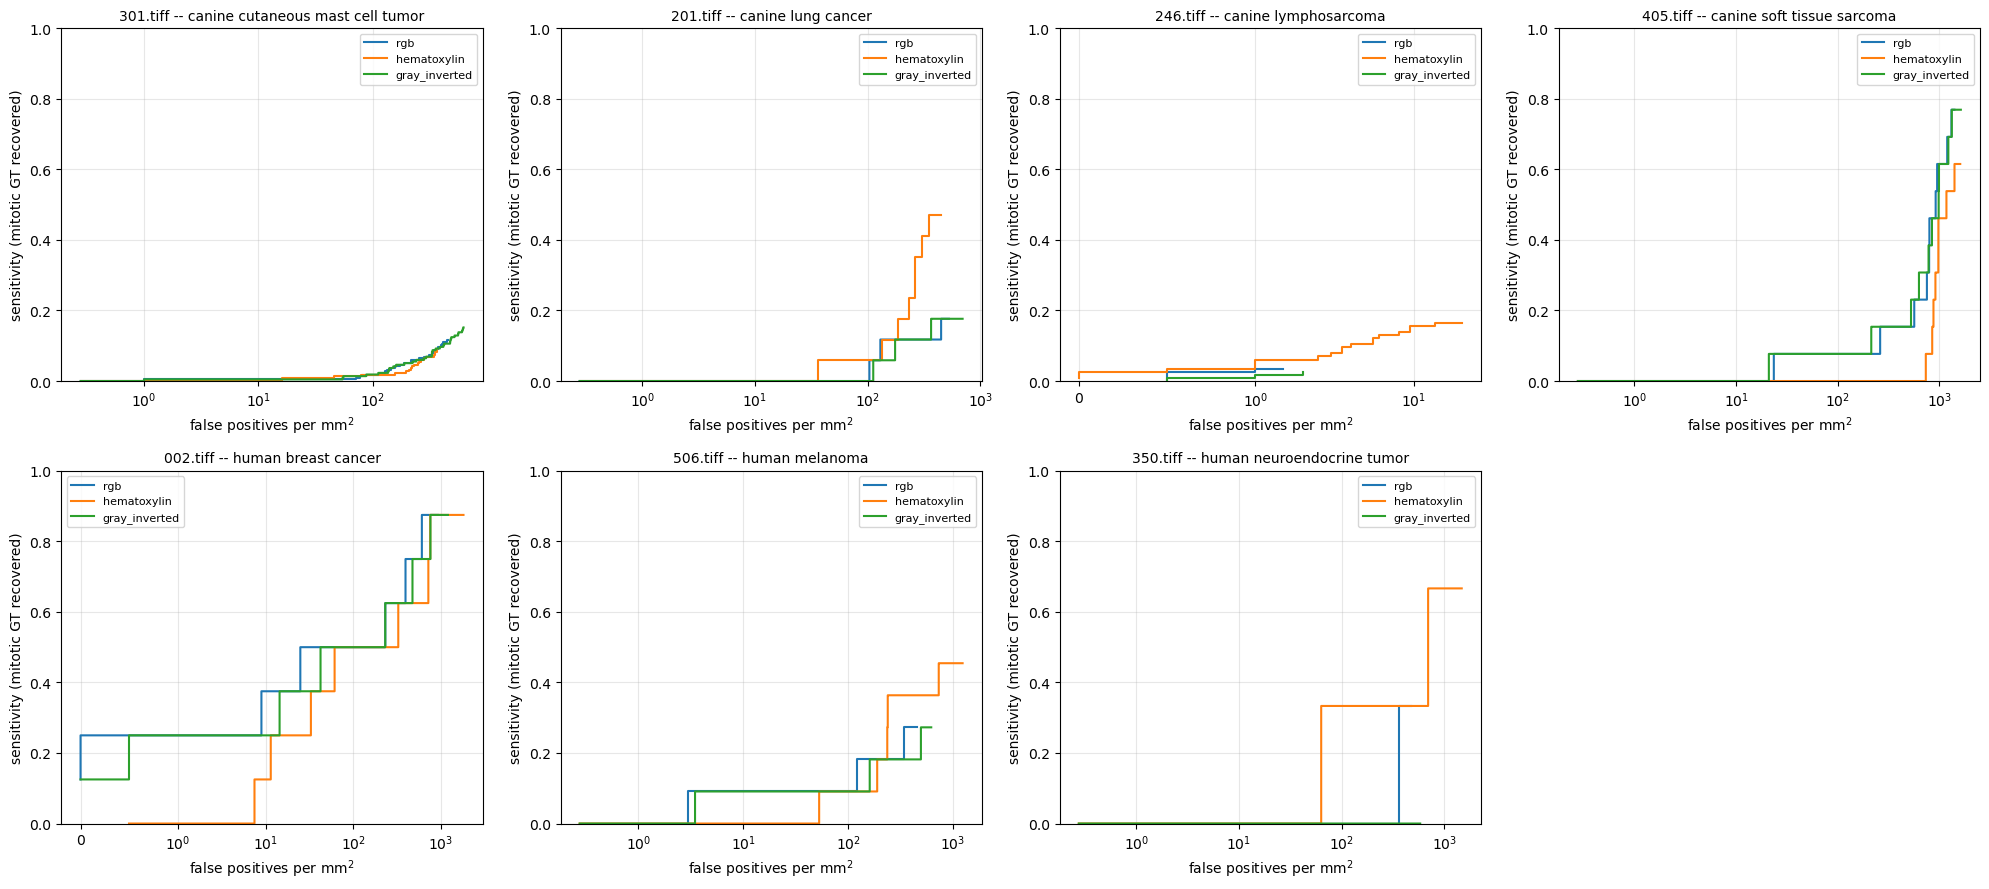

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, fn in zip(axes.ravel(), results.keys()):
    curves = [
        ('rgb', *results[fn]['curve']),
        ('hematoxylin', *results_hem[fn]['curve']),
        ('gray_inverted', *results_gray[fn]['curve']),
    ]
    tumor = selection.loc[selection.file_name == fn, 'tumor_type'].iloc[0]
    viz.froc_plot(curves, ax=ax, title=f'{fn} -- {tumor}')
for ax in axes.ravel()[len(results):]:
    ax.axis('off')
fig.tight_layout(); plt.show()

## Full-list recall ("any annotation hit at all") by channel

Dropping the top-K budget: over the *entire* detection list each channel produced, what
fraction of mitotic GT did it eventually hit (`mitotic_recall`, already in `combined`)?

In [17]:
fulllist_pivot = combined.pivot_table(
    index=['tumor_type', 'file_name'], columns='channel',
    values=['mitotic_recall', 'coverage_frac', 'n_detections_total']
).round(3)
fulllist_pivot = fulllist_pivot.reindex(columns=['gray_inverted', 'hematoxylin', 'rgb'], level=1)
fulllist_pivot

coverage_frac                    mitotic_recall                    n_detections_total                    
channel                                    gray_inverted hematoxylin    rgb  gray_inverted hematoxylin    rgb      gray_inverted hematoxylin     rgb
tumor_type                       file_name                                                                                                          
canine cutaneous mast cell tumor 301.tiff          0.109       0.065  0.081          0.152       0.092  0.115             1280.0       755.0   944.0
canine lung cancer               201.tiff          0.119       0.079  0.090          0.176       0.471  0.176             1393.0       907.0  1053.0
canine lymphosarcoma             246.tiff          0.001       0.005  0.001          0.026       0.165  0.035                7.0        59.0     7.0
canine soft tissue sarcoma       405.tiff          0.272       0.266  0.236          0.769       0.615  0.769             3256.0      3209.0  2815.0
human breast cancer              002.tiff          0.202       0.298  0.157          0.875       0.875  0.875             2419.0      3638.0  1860.0
human melanoma                   506.tiff          0.106       0.204  0.077          0.273       0.455  0.273             1259.0      2507.0   914.0
human neuroendocrine tumor       350.tiff          0.099       0.247  0.081          0.000       0.667  0.333             1181.0      3002.0   956.0

**Read `coverage_frac` and `n_detections_total` alongside `mitotic_recall` before trusting
its ranking** -- `score_threshold=0.5` is the same fixed cutoff for all three channels, but
`TM_CCOEFF_NORMED`'s score distribution is not the same distribution for a raw-RGB template
as for a single-channel one, so "how many peaks clear 0.5" differs by channel for reasons
that have nothing to do with mitosis-specificity. The threshold-free check below removes
that confound instead of trusting a number it can bias.

### Threshold-free check: does one channel actually discriminate mitosis better?

`experiment._probe_variants` reads the raw fused correlation value directly at every
annotated location, every detected-nucleus centroid, and 3000 random tissue points -- no
peaks, no NMS, no score floor. It never tightens the template either (it builds the
augmentation bank straight from `cfg.base_size` around the seed), so it is exactly this
notebook's own untightened, no-augmentation, single-scale configuration -- `base_size=51`,
`n_angles=1`, `flips=(False,)`, `scales=(1.0,)`, all `FSConfig` defaults, `channel` the only
thing varied.

Same seed per image as every other section (pulled from `metrics`, not redrawn).

In [18]:
channel_variants = [
    ('rgb', fs.FSConfig(channel='rgb')),
    ('hematoxylin', fs.FSConfig(channel='hematoxylin')),
    ('gray_inverted', fs.FSConfig(channel='gray_inverted')),
]

t0 = time.time()
probe_rows = []
for _, row in selection.iterrows():
    fn = row['file_name']
    seed_id = int(metrics.loc[(metrics.file_name == fn) &
                              (metrics.method == 'find_and_suppress'), 'seed_ann_id'].iloc[0])
    probe_rows.extend(ex._probe_variants(fn, annotations, seed_id, channel_variants))
    print(f'{fn} done ({time.time()-t0:.0f}s elapsed)', flush=True)

channel_probe = pd.DataFrame(probe_rows)
channel_probe.to_csv('results/fs_raw_seed_channel_probe.csv', index=False)
print(f'\ntotal {time.time()-t0:.0f}s')

301.tiff done (37s elapsed)
201.tiff done (76s elapsed)
246.tiff done (108s elapsed)
405.tiff done (124s elapsed)
002.tiff done (150s elapsed)
506.tiff done (176s elapsed)
350.tiff done (205s elapsed)

total 205s


In [19]:
probe_pivot = channel_probe.merge(
    selection[['file_name', 'tumor_type']], on='file_name'
).pivot_table(
    index=['tumor_type', 'file_name'], columns='variant',
    values=['auc_mitosis_vs_nucleus', 'discrimination', 'median_mitosis_rank']
).round(3)
probe_pivot = probe_pivot.reindex(columns=['gray_inverted', 'hematoxylin', 'rgb'], level=1)
probe_pivot

auc_mitosis_vs_nucleus                    discrimination                    median_mitosis_rank                    
variant                                             gray_inverted hematoxylin    rgb  gray_inverted hematoxylin    rgb       gray_inverted hematoxylin     rgb
tumor_type                       file_name                                                                                                                    
canine cutaneous mast cell tumor 301.tiff                   0.620       0.654  0.627          0.083       0.093  0.086              5820.0      4406.0  5351.0
canine lung cancer               201.tiff                   0.684       0.824  0.712         -0.064      -0.050 -0.062              3315.0       913.0  2711.0
canine lymphosarcoma             246.tiff                   0.843       0.858  0.861          0.034       0.046  0.040               812.0       559.0   464.0
canine soft tissue sarcoma       405.tiff                   0.726       0.722  0.722          0.056       0.037  0.051              1214.0      1328.0  1166.0
human breast cancer              002.tiff                   0.914       0.895  0.923          0.044       0.043  0.045               217.0       315.0   200.0
human melanoma                   506.tiff                   0.744       0.748  0.773          0.076       0.088  0.092              2496.0      2556.0  2396.0
human neuroendocrine tumor       350.tiff                   0.738       0.859  0.796          0.034       0.172  0.080              1747.0       823.0  1390.0

`auc_mitosis_vs_nucleus` = P(a random mitotic figure outscores a random ordinary nucleus)
under that channel's raw fused response, 0.5 = no signal. `discrimination` = that AUC minus
the look-alike-vs-nucleus AUC -- the mitosis-specific part of the signal. `median_mitosis_rank`
is where the typical mitotic figure lands among all ordinary nuclei in the ROI.

In [20]:
def strict_winner(row):
    mx = row.max()
    winners = row.index[row == mx].tolist()
    return winners[0] if len(winners) == 1 else 'tie(' + '/'.join(winners) + ')'

auc_cols = [c for c in probe_pivot.columns if c[0] == 'auc_mitosis_vs_nucleus']
auc_winner = probe_pivot[auc_cols].droplevel(0, axis=1).apply(strict_winner, axis=1)
disc_cols = [c for c in probe_pivot.columns if c[0] == 'discrimination']
disc_winner = probe_pivot[disc_cols].droplevel(0, axis=1).apply(strict_winner, axis=1)
recall_winner = channel_pivot['recall_at_k'].apply(strict_winner, axis=1)
fulllist_recall_winner = fulllist_pivot['mitotic_recall'].apply(strict_winner, axis=1)

# idxmax (used in the two intermediate tables above) silently breaks a tie by picking
# whichever column sorts first alphabetically -- gray_inverted, here, every time. Reporting
# a tie explicitly instead matters: several of these rows genuinely are 3-way or 2-way ties,
# not a real per-domain win for any one channel.
agree = pd.DataFrame({
    'recall_at_k_winner': recall_winner,
    'fulllist_recall_winner': fulllist_recall_winner,
    'auc_winner': auc_winner,
    'discrimination_winner': disc_winner,
})
agree

,,recall_at_k_winner,fulllist_recall_winner,auc_winner,discrimination_winner
tumor_type,file_name,,,,
canine cutaneous mast cell tumor,301.tiff,tie(gray_inverted/hematoxylin/rgb),gray_inverted,hematoxylin,hematoxylin
canine lung cancer,201.tiff,tie(gray_inverted/hematoxylin/rgb),hematoxylin,hematoxylin,hematoxylin
canine lymphosarcoma,246.tiff,hematoxylin,hematoxylin,rgb,hematoxylin
canine soft tissue sarcoma,405.tiff,tie(gray_inverted/hematoxylin/rgb),tie(gray_inverted/rgb),gray_inverted,gray_inverted
human breast cancer,002.tiff,tie(gray_inverted/rgb),tie(gray_inverted/hematoxylin/rgb),rgb,rgb
human melanoma,506.tiff,tie(gray_inverted/rgb),hematoxylin,rgb,rgb
human neuroendocrine tumor,350.tiff,tie(gray_inverted/hematoxylin/rgb),hematoxylin,hematoxylin,hematoxylin


## Verdict: which channel is best?

Per-domain win counts (out of 7) on four different metrics, plus the aggregate mean across
domains for each. Reported as-is, including any disagreement between metrics, rather than
picking whichever one tells the tidiest story -- see the caveat above on why `mitotic_recall`
alone is threshold-confounded and `recall_at_k` alone is noisy on the sparser domains (K
ranges 3-217 across these seven ROIs).

In [21]:
print('Per-domain win counts (7 domains) -- ties reported explicitly, not silently broken:')
for col in ['recall_at_k_winner', 'fulllist_recall_winner', 'auc_winner', 'discrimination_winner']:
    print(f'  {col}: {agree[col].value_counts().to_dict()}')

n_det_246 = combined.loc[combined.file_name == '246.tiff'].set_index('channel')['n_detections_total'].to_dict()
print(f"\n246.tiff (canine lymphosarcoma) n_detections_total by channel: {n_det_246} -- "
      f'orders of magnitude below every other domain (roughly 900-3600 there). Its '
      f'recall_at_k / mitotic_recall result reflects the detection list collapsing at '
      f'score_threshold=0.5, not demonstrated channel quality; its auc/discrimination values '
      f'below are unaffected by this -- the probe reads the fused correlation map directly, '
      f'with no threshold or peak extraction involved.')

print('\nAggregate mean across the 7 domains, by channel:')
agg = combined.groupby('channel')[['recall_at_k', 'mitotic_recall']].mean().round(3)
agg = agg.join(channel_probe.groupby('variant')[['auc_mitosis_vs_nucleus', 'discrimination']].mean().round(3))
agg

Per-domain win counts (7 domains) -- ties reported explicitly, not silently broken:
  recall_at_k_winner: {'tie(gray_inverted/hematoxylin/rgb)': 4, 'tie(gray_inverted/rgb)': 2, 'hematoxylin': 1}
  fulllist_recall_winner: {'hematoxylin': 4, 'gray_inverted': 1, 'tie(gray_inverted/rgb)': 1, 'tie(gray_inverted/hematoxylin/rgb)': 1}
  auc_winner: {'hematoxylin': 3, 'rgb': 3, 'gray_inverted': 1}
  discrimination_winner: {'hematoxylin': 4, 'rgb': 2, 'gray_inverted': 1}

246.tiff (canine lymphosarcoma) n_detections_total by channel: {'rgb': 7, 'hematoxylin': 59, 'gray_inverted': 7} -- orders of magnitude below every other domain (roughly 900-3600 there). Its recall_at_k / mitotic_recall result reflects the detection list collapsing at score_threshold=0.5, not demonstrated channel quality; its auc/discrimination values below are unaffected by this -- the probe reads the fused correlation map directly, with no threshold or peak extraction involved.

Aggregate mean across the 7 domains, by channe

,recall_at_k,mitotic_recall,auc_mitosis_vs_nucleus,discrimination
channel,,,,
gray_inverted,0.055,0.325,0.753,0.038
hematoxylin,0.026,0.477,0.794,0.061
rgb,0.056,0.368,0.773,0.047


## Verdict: which channel is best?

**No channel wins cleanly, and the honest per-domain picture is mostly ties, not the
6/7 sweep a naive read of the tables above would suggest.**

`recall_at_k` (the budgeted top-K metric) is dominated by ties: 4 of 7 domains tie all
three channels at an identical value (three of those at exactly 0.0), 2 more tie
`gray_inverted`/`rgb` against each other, and only `246.tiff` shows a distinct winner --
which is itself a degenerate row (see below). At this sample size (one seed per domain),
`recall_at_k` does not meaningfully separate the three channels at all; **do not read the
apparent "gray_inverted leads" pattern in the tables above as evidence -- it is
`pandas.idxmax` silently resolving every tie in `gray_inverted`'s favour because it sorts
first alphabetically**, not a real per-domain win. The tie-aware win counts two cells up
make this explicit.

**`246.tiff` (canine lymphosarcoma) is a broken measurement for the two thresholded
metrics, not a real data point.** Its detection list clears `score_threshold=0.5` only 7
times (rgb, gray_inverted) or 59 times (hematoxylin) against roughly 900-3,600 on every
other domain -- the top-K budget (K=115 there) never binds, so its `recall_at_k` and
`mitotic_recall` results reflect where each channel's score distribution happens to sit
relative to a fixed threshold, not discrimination quality. Its `auc_mitosis_vs_nucleus`
and `discrimination` values are *not* affected by this -- `experiment._probe_variants`
reads the fused correlation map directly at annotated locations, with no threshold or peak
extraction involved -- so 246.tiff's contribution to the two threshold-free metrics still
stands.

**Once ties and the 246.tiff artifact are accounted for, the threshold-free metrics give
the more usable signal:**

| metric | gray_inverted | hematoxylin | rgb |
|---|---|---|---|
| `mitotic_recall` (full list) -- clear wins, ties excluded | 1 | 4 | 0 |
| `auc_mitosis_vs_nucleus` -- clear wins (no ties at this precision) | 1 | 3 | 3 |
| `discrimination` -- clear wins (no ties at this precision) | 1 | 4 | 2 |

Aggregate mean across the 7 domains:

| channel | recall_at_k | mitotic_recall | auc_mitosis_vs_nucleus | discrimination |
|---|---|---|---|---|
| gray_inverted | 0.055 | 0.325 | 0.753 | 0.038 |
| hematoxylin | 0.026 | **0.477** | **0.794** | **0.061** |
| rgb | 0.056 | 0.368 | 0.773 | 0.047 |

`hematoxylin` leads on every metric not dominated by ties or the 246.tiff artifact --
narrowly on raw AUC (a 3-3 tie in win count with `rgb`, but the higher aggregate mean),
and more clearly on `discrimination` and full-list recall. `rgb` is a genuine second, not a
distant one -- it ties hematoxylin on AUC wins and beats it on discrimination twice
(002.tiff, 506.tiff); `gray_inverted` beats hematoxylin on discrimination once (405.tiff),
so it is not shut out either, just clearly behind on the other six domains. `gray_inverted`
trails on every threshold-free *aggregate* despite the illusory top-K lead described above.

Worth flagging on its own: `discrimination` is negative for **all three channels** on
`201.tiff` (-0.064 gray_inverted / -0.050 hematoxylin / -0.062 rgb) -- on that domain every
channel's raw response ranks look-alikes above mitoses *better* than it ranks mitoses above
ordinary nuclei, i.e. none of the three carry mitosis-specific signal there. Hematoxylin
"wins" that row only by being the least negative of three bad numbers, and that row is one
of its four counted discrimination wins -- a tally win, not evidence the channel actually
discriminates mitosis on that domain. The same caution already applied to 246.tiff above
applies here: count the win, but don't read it as a clean success.

**Two reasons to hold this loosely rather than call it settled.** First,
`Research Logs/design_choices.md` section 3 predicted hematoxylin's benefit would be
cross-scanner *consistency*, not mitosis-vs-lookalike *specificity* -- and specifically
warned that `nucleus_blobs` already operates in hematoxylin space and still cannot
separate the two classes. This run's discrimination margin (hematoxylin 0.061 vs. rgb's
0.047) does not contradict that caveat; a channel can rank mitoses above ordinary nuclei
somewhat better while still not being demonstrated as classifying mitosis specifically
better than a look-alike. Second, a meaningful share of hematoxylin's discrimination
margin is carried by `350.tiff`, whose probe is built from only `n_mitotic=3` mitotic
figures -- hematoxylin's discrimination there (0.172) is more than double its nearest
rival (rgb, 0.080) and pulls the aggregate mean up on its own; that domain's `K=3` is the
same small-sample concern the `recall_at_k` caveat already raises, just showing up in a
different metric. Excluding just `350.tiff`, hematoxylin's discrimination win count over
`rgb` narrows from 4-2 to 3-2 -- still a lead, but a thinner one than "wins 4/7" suggests,
since one of the four wins came from a 3-mitotic-figure sample.

**Bottom line**: `hematoxylin` is the best-supported answer to "which channel discriminates
mitosis best" once thresholded metrics and their tie/degenerate-row artifacts are set
aside, with `rgb` a close second and `gray_inverted` the weakest of the three on every
threshold-free measure. That ranking rests on 7 single-seed domains, is not statistically
decisive (`rgb` ties on AUC, and the margin depends partly on one thin-sample domain), and
does not establish that hematoxylin's signal is mitosis-specific rather than merely
chromatin-selective -- only that, on this run, it ranks mitotic figures above ordinary
nuclei somewhat more reliably than the other two channels do. None of this changes
`design_choices.md`'s own known-limitation caveat: at these AUCs, hundreds of ordinary
nuclei still outrank a typical mitotic figure by score alone, so "best channel" here means
least bad, not solved.

## Raw box vs. Otsu-tightened box: is tightening worth it?

The obvious way to answer this would be to diff this notebook's saved metrics against
[`find_and_suppress_midog_simple.ipynb`](find_and_suppress_midog_simple.ipynb)'s (the
`tighten_bbox=True` run). **That comparison is confounded and was checked, not assumed:**
`tighten_bbox=True`'s seed selection runs an extra foreground/connected-component filter
(`seed_selection.foreground_filter`) that `tighten_bbox=False` skips, which changes the
candidate *pool* each domain draws its seed from -- so the same `(seed=0, image_id)` RNG
draw can land on a different annotation. Checking directly: **4 of the 7 domains picked a
different `seed_ann_id` between the two saved runs** (301, 201, 246, 405.tiff), leaving
only 3 (002, 506, 350.tiff) where the two notebooks happen to share a seed. Diffing the
full 7-domain tables would mostly be comparing different mitotic figures, not the same
figure under two template-extraction methods.

**Controlled design instead**: reuse *this* notebook's own 7 seed annotations (the ones
already verified identical across all three channels above), and for each one compute
what its Otsu-tightened box would have been (`seed_selection.tightened_base_size`, same
structural channel and window `pick_seed` itself uses). That holds the annotated object,
the channel, and everything else fixed, varying only the template's extraction method --
raw 51px box vs. tightened native size.

In [1]:
from midog_utils import seed_selection as ss

seed_rows = metrics[metrics.method == 'find_and_suppress'][['file_name', 'seed_ann_id']].reset_index(drop=True)
tighten_info = []
for _, row in seed_rows.iterrows():
    fn, ann_id = row['file_name'], int(row['seed_ann_id'])
    rgb_img = ds.load_roi(f'images/{fn}')
    gray_inv = ch.to_gray_inverted(rgb_img)
    ann = annotations[annotations.ann_id == ann_id].iloc[0]
    tsize = ss.tightened_base_size(gray_inv, ann['cx'], ann['cy'])
    tighten_info.append({'file_name': fn, 'seed_ann_id': ann_id, 'raw_size': cfg.base_size,
                          'tightened_size': tsize, 'tightenable': tsize is not None})
    del rgb_img, gray_inv

tighten_info = pd.DataFrame(tighten_info)
tighten_info

  file_name  seed_ann_id  raw_size  tightened_size  tightenable
0  301.tiff        14969        51            41.0         True
1  201.tiff         4457        51            51.0         True
2  246.tiff         6548        51            41.0         True
3  405.tiff        20563        51             NaN        False
4  002.tiff           18        51            35.0         True
5  506.tiff        24233        51            43.0         True
6  350.tiff        18164        51            41.0         True

6 of the 7 seeds are tightenable at all -- **405.tiff's raw-run seed is not**: its click
does not land inside a clean, size/shape-valid Otsu component, so under `tighten_bbox=True`
this exact annotation could never have been selected as a seed in the first place (matching
the earlier finding that the two saved runs disagree on 405.tiff's `seed_ann_id`). It is
excluded from the paired comparison below rather than silently dropped -- a real, structural
difference between the two configurations' candidate pools, not a missing data point.

### Threshold-free comparison: does tightening improve discrimination, holding the object fixed?

Same tool as the channel comparison above (`experiment._probe_variants`) -- reads the raw
fused correlation value at every annotated location, detected-nucleus centroid, and 3000
random tissue points, no score threshold or top-K budget involved. Run once per domain with
6 variants (3 channels x {raw 51px, tightened native size}), reusing one nucleus
segmentation across all 6.

In [2]:
t0 = time.time()
tighten_probe_rows = []
for _, r in tighten_info[tighten_info.tightenable].iterrows():
    fn, ann_id, tsize = r['file_name'], int(r['seed_ann_id']), int(r['tightened_size'])
    variants = []
    for chan in ['rgb', 'hematoxylin', 'gray_inverted']:
        variants.append((f'{chan}_raw51', fs.FSConfig(channel=chan, base_size=51)))
        variants.append((f'{chan}_tightened{tsize}', fs.FSConfig(channel=chan, base_size=tsize)))
    tighten_probe_rows.extend(ex._probe_variants(fn, annotations, ann_id, variants))
    print(f'{fn} done ({time.time()-t0:.0f}s elapsed)', flush=True)

tighten_probe = pd.DataFrame(tighten_probe_rows)
tighten_probe['channel'] = tighten_probe['variant'].str.split('_').str[0]
tighten_probe['extraction'] = np.where(tighten_probe['variant'].str.contains('raw51'), 'raw_51px', 'tightened')
tighten_probe.to_csv('results/fs_raw_vs_tightened_probe.csv', index=False)
print(f'\ntotal {time.time()-t0:.0f}s')

301.tiff done (480s elapsed)
201.tiff done (638s elapsed)
246.tiff done (711s elapsed)
002.tiff done (873s elapsed)
506.tiff done (1259s elapsed)
350.tiff done (1467s elapsed)

total 1467s


In [3]:
def strict_winner(row):
    mx = row.max()
    winners = row.index[row == mx].tolist()
    return winners[0] if len(winners) == 1 else 'tie(' + '/'.join(winners) + ')'

tp = tighten_probe.merge(selection[['file_name', 'tumor_type']], on='file_name')
disc_pivot = tp.pivot_table(index=['tumor_type', 'file_name', 'channel'], columns='extraction',
                            values='discrimination').round(3)
auc_pivot = tp.pivot_table(index=['tumor_type', 'file_name', 'channel'], columns='extraction',
                           values='auc_mitosis_vs_nucleus').round(3)

print('=== discrimination: raw_51px vs tightened, by domain x channel (18 rows = 6 domains x 3 channels) ===')
print(disc_pivot)
disc_winner = disc_pivot.apply(strict_winner, axis=1)
print(f'\nwin counts: {disc_winner.value_counts().to_dict()}')

print('\n=== auc_mitosis_vs_nucleus: raw_51px vs tightened ===')
print(auc_pivot)
auc_winner = auc_pivot.apply(strict_winner, axis=1)
print(f'\nwin counts: {auc_winner.value_counts().to_dict()}')

print('\n=== aggregate mean across the 18 (domain x channel) rows ===')
print(tp.groupby('extraction')[['auc_mitosis_vs_nucleus', 'discrimination']].mean().round(4))

=== discrimination: raw_51px vs tightened, by domain x channel (18 rows = 6 domains x 3 channels) ===
extraction                                              raw_51px  tightened
tumor_type                       file_name channel                         
canine cutaneous mast cell tumor 301.tiff  gray            0.083      0.078
                                           hematoxylin     0.093      0.075
                                           rgb             0.086      0.079
canine lung cancer               201.tiff  gray           -0.064     -0.064
                                           hematoxylin    -0.050     -0.050
                                           rgb            -0.062     -0.062
canine lymphosarcoma             246.tiff  gray            0.034      0.047
                                           hematoxylin     0.046      0.039
                                           rgb             0.040      0.052
human breast cancer              002.tiff  gray            0.0

### Matched-seed detection pipeline: what actually happens at `score_threshold=0.5`?

The threshold-free probe isolates signal quality, but the real pipeline runs a fixed
`score_threshold=0.5` and a top-K budget -- and `TM_CCOEFF_NORMED`'s null variance shrinks
as template pixel count grows (`FSConfig.scales`'s own docstring, `design_choices.md`
sections 2 and 7b), so a *smaller* tightened template is expected to inflate the detection
list independent of any discrimination gain. Checking that directly: run
`find_and_suppress` on the same fixed seed at both sizes (bypassing `pick_seed`'s random
draw entirely, since the seed is already fixed here), rgb channel only (the primary channel
both source notebooks used for their main pass).

In [4]:
def run_fixed_seed(file_name, ann_id, channel, base_size, annotations, images_dir='images'):
    path = f'{images_dir}/{file_name}'
    rgb_img = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    area_mm2 = ds.check_roi_scale(path, rgb_img.shape)
    radius = ev.radius_px(mpp)
    gt = ds.image_annotations(annotations, file_name)
    seed = gt[gt['ann_id'] == ann_id].iloc[0]
    gt_eval = gt[gt['ann_id'] != ann_id].reset_index(drop=True)
    run_cfg = fs.FSConfig(channel=channel, base_size=base_size)
    img = ch.to_channel(rgb_img, run_cfg.channel)
    det, info = fs.find_and_suppress(img, (seed['cx'], seed['cy']), run_cfg, nms_radius=radius)
    det_out, gt_out, m, curve = ev.evaluate_run(det, gt_eval, radius, area_mm2, roi_shape=rgb_img.shape)
    del rgb_img
    return {'file_name': file_name, 'seed_ann_id': ann_id, 'base_size': base_size, **m, **info}

t0 = time.time()
fixed_seed_rows = []
for _, r in tighten_info[tighten_info.tightenable].iterrows():
    fn, ann_id, tsize = r['file_name'], int(r['seed_ann_id']), int(r['tightened_size'])
    fixed_seed_rows.append(run_fixed_seed(fn, ann_id, 'rgb', 51, annotations))
    fixed_seed_rows.append(run_fixed_seed(fn, ann_id, 'rgb', tsize, annotations))
    print(f'{fn} done ({time.time()-t0:.0f}s elapsed)', flush=True)

fixed_seed_metrics = pd.DataFrame(fixed_seed_rows)
fixed_seed_metrics.to_csv('results/fs_raw_vs_tightened_rgb_metrics.csv', index=False)
print(f'\ntotal {time.time()-t0:.0f}s')

fsm = fixed_seed_metrics.merge(selection[['file_name', 'tumor_type']], on='file_name')
# Label by row order (raw appended first, tightened second per domain), not by base_size
# value -- 201.tiff's Otsu-tightened size happens to equal 51 (no smaller component found),
# so a base_size==51 test would silently collide both its rows onto 'raw_51px' and leave
# 'tightened' entirely NaN for that one domain. Order is deterministic per the loop above.
fsm['extraction'] = fsm.groupby('file_name').cumcount().map({0: 'raw_51px', 1: 'tightened'})
det_pivot = fsm.pivot_table(index=['tumor_type', 'file_name'], columns='extraction',
                            values=['recall_at_k', 'mitotic_recall', 'coverage_frac', 'n_detections_total'],
                            aggfunc='first').round(4)
det_pivot

301.tiff done (15s elapsed)
201.tiff done (32s elapsed)
246.tiff done (48s elapsed)
002.tiff done (69s elapsed)
506.tiff done (92s elapsed)
350.tiff done (111s elapsed)

total 111s


coverage_frac  ... recall_at_k
extraction                                      raw_51px  ...   tightened
tumor_type                       file_name                ...            
canine cutaneous mast cell tumor 301.tiff         0.0812  ...      0.0276
canine lung cancer               201.tiff         0.0902  ...      0.0000
canine lymphosarcoma             246.tiff         0.0006  ...      0.2783
human breast cancer              002.tiff         0.1570  ...      0.2500
human melanoma                   506.tiff         0.0774  ...      0.0909
human neuroendocrine tumor       350.tiff         0.0810  ...      0.0000

[6 rows x 8 columns]

## Verdict: raw box or tightened box?

**Threshold-free (signal-quality) comparison: a wash.** Across the 18 domain x channel
rows (6 tightenable domains x 3 channels): `raw_51px` wins the aggregate mean AUC (0.7818
vs. 0.7727, a 0.009 gap), `tightened` wins the aggregate mean discrimination (0.0566 vs.
0.0489, a 0.008 gap). Win counts split similarly -- AUC: raw 10, tightened 5, tied 3;
discrimination: tightened 8, raw 7, tied 3. Both gaps are small relative to the spread
across the 18 rows; this measure, which involves no threshold or peak extraction, does not
support a general "tightening improves matching quality" claim in either direction.

**The actual thresholded pipeline (matched seed, `score_threshold=0.5`, rgb channel):
tightening wins two of the four real comparisons, ties the rest.** Decomposed by
`topk_tp` / `topk_fp_lookalike` at the identical top-K budget:

| domain | raw topk_tp | tightened topk_tp | note |
|---|---|---|---|
| 301.tiff | 4 | 6 | **tightened wins** -- ranking quality: +2 TP, -2 lookalike-FP at the same 217-item budget, both lists far exceed K so this isn't a list-length effect |
| 246.tiff | 4 | 32 | **tightened wins** -- differently: raw's search essentially fails at this threshold (only 7 total detections against 115 mitotic GT in a 2mm^2 ROI); tightening recovers a usable list. Neither list reaches K=115, so this *is* "how many mitoses cleared threshold at all," not a ranking-quality comparison -- a real, if differently-shaped, win for tightening on this domain |
| 201.tiff | 0 | 0 | not a comparison -- Otsu found the tightened box *is* 51px here (no smaller component), so both runs use the identical template |
| 002.tiff | 2 | 2 | identical bucket outcome |
| 506.tiff | 1 | 1 | identical bucket outcome |
| 350.tiff | 0 | 0 | identical bucket outcome (both miss entirely, K=3) |

So: two wins (301, 246 -- for different reasons), three ties (002, 506, 350), one no-op
(201) where the two configurations coincide.

**Tightening reliably costs a longer, noisier candidate list at a fixed threshold.**
Averaged across the 6 domains: `coverage_frac` roughly doubles (0.081 -> 0.165) and
`n_detections_total` roughly doubles (956 -> 2019) under tightening. This matches the
mechanism `FSConfig.scales`'s own docstring and `design_choices.md` sections 2 / 7b
describe: `TM_CCOEFF_NORMED`'s null variance shrinks as template pixel count grows, so a
smaller (tightened) template inflates scores everywhere, not just at true objects -- more
noise clears the same fixed threshold. This is also *why* 246.tiff's raw list nearly
collapses to 7 items: it isn't that raw ranks badly there, it's that raw's larger template
produces a tighter score distribution that a 0.5 floor barely clears at all on that domain.
The list is not yet saturated (`coverage_frac` tops out at 0.29 here, well under the
~0.85-0.97 range flagged as meaningless in the original single-pass run), but the
direction and rough magnitude match the documented prediction.

**A confound worth naming rather than papering over: raw and tightened templates don't
put scores on a comparable scale**, so every fixed-`score_threshold=0.5` comparison in
this section is partly a comparison of two different templates and partly a comparison of
where a fixed threshold happens to fall on each one's score distribution. 246.tiff's win
is the clearest example -- it reads as much about threshold placement as about which
template finds mitoses better. Nothing here re-calibrates the threshold per template size
or compares the two at a matched budget/coverage instead of a matched score cutoff; that
would be the natural next check, not done here.

**Two of the seven domains show the tightening machinery not actually biting**, worth
noting on its own: 201.tiff's Otsu box comes out at exactly 51px (no smaller component
found -- tightening is a no-op), and 405.tiff's raw-run seed fails the foreground filter
entirely (tightening's seed-selection would have picked a *different* annotation there, not
merely a differently-sized template of the same one -- excluded from this comparison for
exactly that reason). Roughly 2 of 7 domains sampled here, tightening either changes
nothing or changes which object gets seeded, not just how large the template is.

**Bottom line: not a clean verdict either way.** Signal quality is a wash between raw and
tightened (small gaps, split across two different threshold-free metrics). The actual
pipeline's matched-budget comparison favours tightening on the domains where it produces a
difference at all (2 wins, 0 losses, 3 ties, 1 no-op) -- but that favourable read is
entangled with the threshold-scale confound just described, and comes paired with a
roughly 2x longer, noisier candidate list at the same fixed threshold. The most defensible
claim from this run is `design_choices.md` section 8's own framing: bbox tightening is not
a validated improvement, and this comparison doesn't settle it -- it shows tightening is
not obviously *worse* on matching quality, is sometimes meaningfully better at recovering a
usable candidate list on threshold-starved domains, and reliably costs a bigger list to
sift through. Whether that trade is worth the added seed-selection complexity (Otsu,
connected components, the size/shape sanity checks) depends on what the list is *for* --
a fixed downstream budget favours tightening's occasional recovery wins, a fixed score
cutoff a reviewer has to sift by hand favours raw's shorter, cheaper list.